# Correlation With Temperature



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NYC_Data.csv to NYC_Data (4).csv
Saving NYC_Weather_2016_2022.csv to NYC_Weather_2016_2022 (4).csv


Correlation with temperature in 2019:
Carbon monoxide   -0.353498
NO2               -0.484513
Ozone              0.556257
PM2.5             -0.193503
Name: temperature_C, dtype: float64


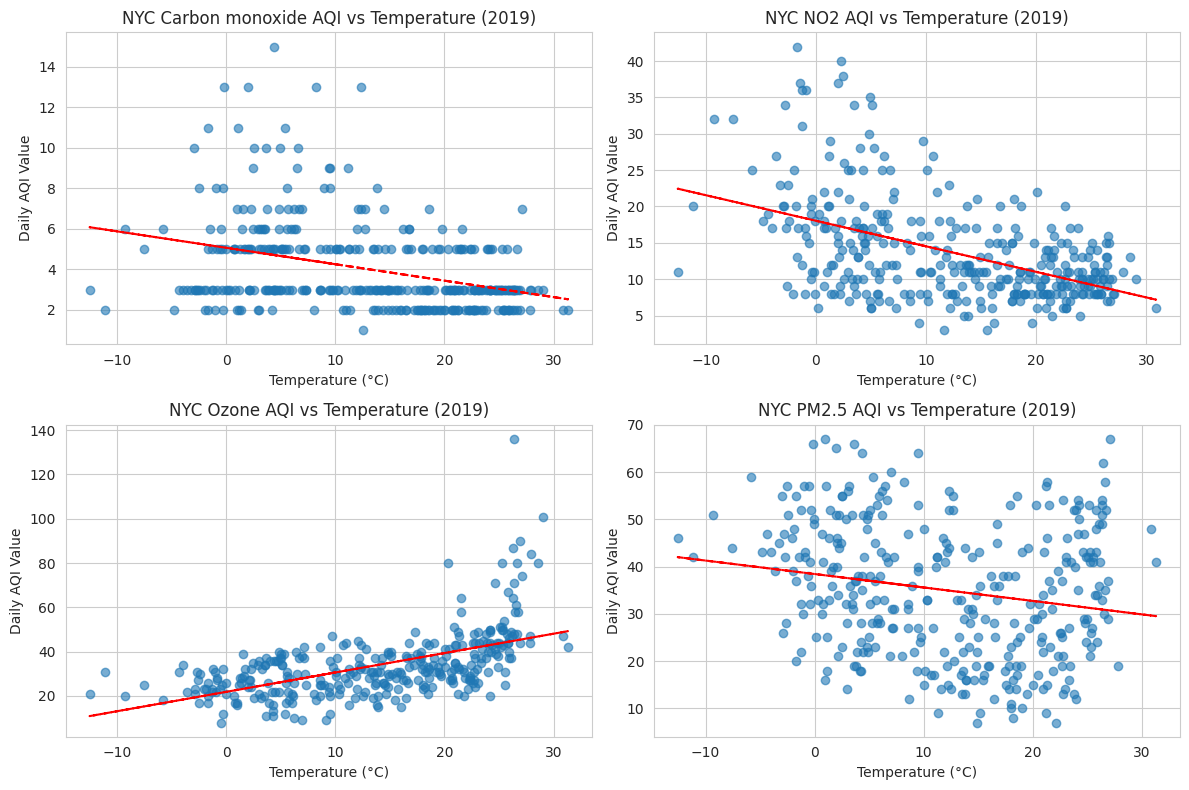

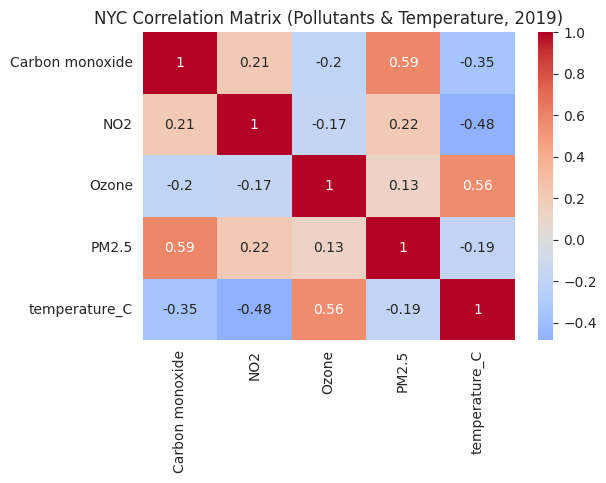

In [ ]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

aqi_df = pd.read_csv("NYC_Data.csv")
try:
    weather_df = pd.read_csv("NYC_Weather_2016_2022.csv", encoding='latin-1')
except UnicodeDecodeError:
    weather_df = pd.read_csv("NYC_Weather_2016_2022.csv", encoding='cp1252')

weather_df.rename(columns={'temperature (¡C) ': 'temperature_C'}, inplace=True)

aqi_df['Date'] = pd.to_datetime(aqi_df['Date'], errors='coerce')
weather_df['time'] = pd.to_datetime(weather_df['time'], errors='coerce')

aqi_2019 = aqi_df[aqi_df['Date'].dt.year == 2019]
weather_2019 = weather_df[weather_df['time'].dt.year == 2019].copy()

pollutants = ["Carbon monoxide", "NO2", "Ozone", "PM2.5"]
aqi_2019 = aqi_2019[aqi_2019['Pollutant'].isin(pollutants)]

aqi_pivot = aqi_2019.pivot_table(
    index="Date",
    columns="Pollutant",
    values="Daily AQI Value"
).reset_index()

weather_2019_daily = weather_2019.set_index('time').resample('D')['temperature_C'].mean().reset_index()
weather_2019_daily.rename(columns={'time': 'Date'}, inplace=True)

merged = pd.merge(aqi_pivot, weather_2019_daily, left_on="Date", right_on="Date")

present_pollutants = [p for p in pollutants if p in merged.columns]


corrs = merged[present_pollutants + ["temperature_C"]].corr()
print("Correlation with temperature in 2019:")
print(corrs["temperature_C"].drop("temperature_C"))

plt.figure(figsize=(12,8))
for i, pollutant in enumerate(present_pollutants, 1):
    plt.subplot(2, 2, i)
    plt.scatter(merged["temperature_C"], merged[pollutant], alpha=0.6)

    temp_df = merged[["temperature_C", pollutant]].dropna()
    z = np.polyfit(temp_df["temperature_C"], temp_df[pollutant], 1)
    p = np.poly1d(z)
    plt.plot(temp_df["temperature_C"], p(temp_df["temperature_C"]), "r--")
    plt.title(f"NYC {pollutant} AQI vs Temperature (2019)")
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Daily AQI Value")
    plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(corrs, annot=True, cmap="coolwarm", center=0)
plt.title("NYC Correlation Matrix (Pollutants & Temperature, 2019)")
plt.show()